# 篇末综合 局部规则与宏观近似

## 学习目标与先修知识

在局部规则、演化和空间模型（model）中检查宏观近似的条件。

先修：12.1—12.5 局部规则、收益、有限抽样、空间离散与宏观统计。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

同一个局部规则可能生成不同空间排列；同一个频率可来自不同演化机制。如何定义模型、检验数值结果，再判断宏观近似何时失效？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先预测两条同密度二值环的下一步；再想清收益、随机抽样与空间反应各自需要什么额外规则。

In [2]:
a=[1,0,1,0];b=[1,1,0,0]
pair=lambda s:sum(s[(i-1)%4]*s[(i+1)%4] for i in range(4))/4
print('密度同为',sum(a)/4,'；隔一格相关',pair(a),pair(b))

密度同为 0.5 ；隔一格相关 0.5 0.0


## 模型假设

篇末题组的每题独立给足输入（input）。各题分别连接局部异或、两类型收益、有限抽样与 Schnakenberg 反应扩散（reaction-diffusion）模型。

## 数学解释与推导

局部异或聚合满足 $p'=2p-2c_2$；把 $c_2$ 换成 $p^2$ 需要独立性。复制动态（replicator dynamics） $\dot p=p(1-p)(f_0-f_1)$ 则需要充分混合、连续频率假设；有限个体抽样的条件方差（variance）为 $p(1-p)/N$。空间反应模型须把无反应纯扩散的守恒检查（conservation check）、均匀平衡（equilibrium）局部稳定及非零模态（mode）增长分开检验。每种机制采用相应的检查量。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def ca_step(state, boundary, mode, order):
    """Binary rule 90: the next bit is the XOR of its two old/current neighbors."""
    n = len(state)
    result = list(state)

    def neighbor(values, index):
        if boundary == 'periodic':
            return values[index % n]
        return values[index] if 0 <= index < n else 0

    if mode == 'sync':
        old = list(state)
        return [neighbor(old, i - 1) ^ neighbor(old, i + 1) for i in range(n)]
    for i in order:
        result[i] = neighbor(result, i - 1) ^ neighbor(result, i + 1)
    return result


def ca_features(state):
    """Density and distance-two pair fraction for periodic binary cells."""
    n = len(state)
    density = sum(state) / n
    pair_two = sum(state[(i - 1) % n] * state[(i + 1) % n] for i in range(n)) / n
    return [density, pair_two]


def ca_density_predictions(state):
    """Mean-field independence vs exact closure with one pair statistic."""
    density, pair_two = ca_features(state)
    return [2 * density * (1 - density), 2 * density - 2 * pair_two]


def payoff_and_replicator(matrix, p):
    """Type 0 frequency p, type 1 frequency 1-p."""
    f0 = p * matrix[0][0] + (1 - p) * matrix[0][1]
    f1 = p * matrix[1][0] + (1 - p) * matrix[1][1]
    mean = p * f0 + (1 - p) * f1
    return [f0, f1, mean, p * (f0 - mean)]


def neutral_step(p, draws):
    """One Wright-Fisher-style generation with supplied independent U[0,1) draws."""
    return sum(value < p for value in draws) / len(draws)


def reaction_diffusion_step(u, v, a, b, du, dv, dx, dt, boundary):
    """Schnakenberg reaction plus nearest-neighbor diffusion in one dimension."""
    n = len(u)
    next_u, next_v = [], []
    for i in range(n):
        left = (i - 1) % n if boundary == 'periodic' else max(0, i - 1)
        right = (i + 1) % n if boundary == 'periodic' else min(n - 1, i + 1)
        lap_u = (u[left] - 2 * u[i] + u[right]) / dx**2
        lap_v = (v[left] - 2 * v[i] + v[right]) / dx**2
        react_u = a - u[i] + u[i]**2 * v[i]
        react_v = b - u[i]**2 * v[i]
        next_u.append(u[i] + dt * (react_u + du * lap_u))
        next_v.append(v[i] + dt * (react_v + dv * lap_v))
    return [next_u, next_v]

## 对照实验

并列展示同密度局部结构、收益频率方向与空间均匀态一步；每个结果仍按各自模型假设解读。

复制动态 p=.5 的导数 -0.25
均匀反应扩散一步 [[1.0, 1.0, 1.0], [0.9, 0.9, 0.9]]


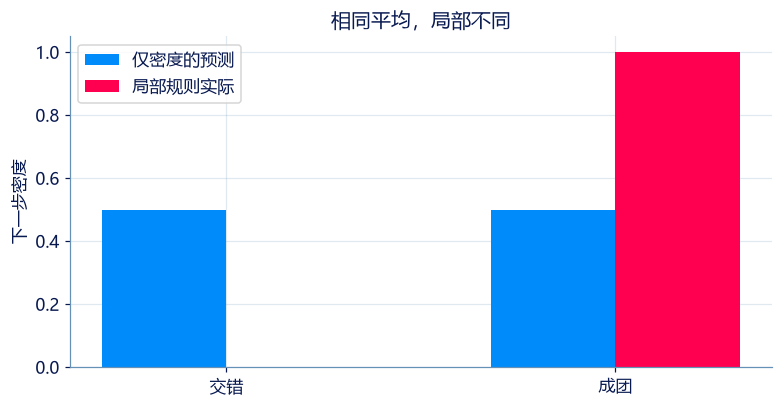

In [4]:
states=[[1,0,1,0],[1,1,0,0]]
rows=[]
for state in states:
    rows.append([ca_features(state)[0],ca_density_predictions(state)[0],
                 sum(ca_step(state,'periodic','sync',list(range(4))))/4])
M=[[3.,0.],[4.,1.]]
print('复制动态 p=.5 的导数',payoff_and_replicator(M,.5)[3])
print('均匀反应扩散一步',reaction_diffusion_step([1.]*3,[.9]*3,.1,.9,.01,1.,1.,.1,'periodic'))
fig,ax=plt.subplots(figsize=(7,3.6))
x=np.arange(2)
ax.bar(x-.16,[r[1] for r in rows],width=.32,color=BLUE,label='仅密度的预测')
ax.bar(x+.16,[r[2] for r in rows],width=.32,color=PINK,label='局部规则实际')
ax.set(xticks=x,xticklabels=['交错','成团'],ylim=(0,1.05),ylabel='下一步密度',title='相同平均，局部不同')
ax.legend();plt.show()

## 结果解释

初态密度相同却产生不同下一步结果，说明该宏观闭合遗漏相关性。收益方程、随机抽样和空间反应在后续题目中分别计算各自的状态（state）变化。

### 独立核对

独立核对异或微观更新、复制导数（derivative）、零扩散均匀反应和中性吸收边界。

In [5]:
assert rows[0][0]==rows[1][0]==.5 and rows[0][2]!=rows[1][2]
np.testing.assert_allclose(payoff_and_replicator(M,.5)[3],-.25)
np.testing.assert_allclose(reaction_diffusion_step([1.]*3,[.9]*3,.1,.9,.01,1.,1.,.1,'periodic'),[[1.]*3,[.9]*3])
assert neutral_step(0.,[.1,.2,.3])==0.
print('四类机制的最小独立边界核对通过。')

四类机制的最小独立边界核对通过。


## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 单项选择题：先定义邻域和边界

要在另一台电脑复现局部二值演化，哪组记录充分且必要？

- **A.** 初态、邻域与规则、边界、同步或异步顺序。
- **B.** 只提供一张末态图片。
- **C.** 只记录动画帧率。
- **D.** 只记录总密度。

[作答：先定义邻域和边界](http://127.0.0.1:8000/parts/12-%E4%B8%AA%E4%BD%93%E4%B8%8E%E9%9B%86%E4%BD%93%E7%8E%B0%E8%B1%A1/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p12-capstone-neighborhood)

### 第 2 题 · 基础辨析 · 10 分 · 单项选择题：选择与漂变分开

频率变化可能来自选择、变异与有限抽样。以下哪项比较更能区分机制？

- **A.** 固定 N 和初态，逐项关闭 s、μ，并重复抽样。
- **B.** 只观察一条上升轨迹（trajectory）。
- **C.** 同时改变 N、收益和边界却归因于选择。
- **D.** 把收益当概率（probability）且不声明映射。

[作答：选择与漂变分开](http://127.0.0.1:8000/parts/12-%E4%B8%AA%E4%BD%93%E4%B8%8E%E9%9B%86%E4%BD%93%E7%8E%B0%E8%B1%A1/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p12-capstone-mechanisms)

### 第 3 题 · 方法应用 · 15 分 · Python 计算题：同步局部更新的最小实现

给定周期或固定边界（fixed boundary）下的二值异或规则，实施一次同步更新（synchronous update）。注意全部新值只读取同一行旧状态（state）。

**函数与代码模板**

```python
def solve(
    state: list[int],
    boundary: str,
    mode: str,
    order: list[int],
) -> list[int]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[int]` | 至少3格的二值初态。 | 类别 |
| `boundary` | `str` | periodic 或 fixed。 | 类别 |
| `mode` | `str` | 固定为 sync。 | 类别 |
| `order` | `list[int]` | 统一接口中的完整索引表。 | 编号 |

**返回值**

直接返回 updated（list[int]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `updated` | `list[int]` | 同步下一行。 | 类别 |

**计算规则**

与 12.1.1 相同规则，但本题含另一组迁移初态。

**约束与边界**

- 只使用题定的有限状态、固定输入（input）与明示更新规则；不从图形猜测答案。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 至少3格的二值初态。 | [0, 1, 0, 0, 0] | 类别 |
| boundary | periodic 或 fixed。 | fixed | 类别 |
| mode | 固定为 sync。 | sync | 类别 |
| order | 统一接口中的完整索引表。 | [0, 1, 2, 3, 4] | 编号 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [0, 1, 0, 0, 0]
boundary = 'fixed'
mode = 'sync'
order = [0, 1, 2, 3, 4]

result = solve(state, boundary, mode, order)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| updated | 同步下一行。 | [1, 0, 1, 0, 0] | 类别 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1, 0, 1, 0, 0]
```

**样例解释**

边界外值和旧状态时序均须明确。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：同步局部更新的最小实现](http://127.0.0.1:8000/parts/12-%E4%B8%AA%E4%BD%93%E4%B8%8E%E9%9B%86%E4%BD%93%E7%8E%B0%E8%B1%A1/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p12-capstone-ca)

### 第 4 题 · 方法应用 · 15 分 · Python 计算题：从收益到类型频率变化

类型0频率 p 与 2×2 行对列收益矩阵（payoff matrix）给定，返回两类收益、平均收益及连续复制动态（replicator dynamics）导数（derivative）。表中收益数值按相对适合度率（fitness rate）解释，单位1/T。

**函数与代码模板**

```python
def solve(
    matrix: list[list[float]],
    p: float,
) -> tuple[float, float, float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 2×2 收益矩阵。 | 1/T |
| `p` | `float` | 类型0频率。 | 1 |

**返回值**

按以下顺序返回元组：(f0, f1, mean, dpdt)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `f0` | `float` | 类型0收益。 | 1/T |
| `f1` | `float` | 类型1收益。 | 1/T |
| `mean` | `float` | 频率加权收益。 | 1/T |
| `dpdt` | `float` | 频率导数。 | 1/T |

**计算规则**

计算规则与 12.2.1 相同，但新收益表可能有内部等收益点。

**约束与边界**

- 只使用题定的有限状态（state）、固定输入（input）与明示更新规则；不从图形猜测答案。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| matrix | 2×2 收益矩阵。 | [[2.0, 1.0], [0.0, 3.0]] | 1/T |
| p | 类型0频率。 | 0.4 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
matrix = [[2.0, 1.0], [0.0, 3.0]]
p = 0.4

result = solve(matrix, p)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| f0 | 类型0收益。 | 1.4 | 1/T |
| f1 | 类型1收益。 | 1.8 | 1/T |
| mean | 频率加权收益。 | 1.64 | 1/T |
| dpdt | 频率导数。 | -0.096 | 1/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.4,
                   1.7999999999999998,
                   1.6399999999999997,
                   -0.09599999999999992)
```

**样例解释**

返回导数而不是任意步长后的概率（probability）。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：从收益到类型频率变化](http://127.0.0.1:8000/parts/12-%E4%B8%AA%E4%BD%93%E4%B8%8E%E9%9B%86%E4%BD%93%E7%8E%B0%E8%B1%A1/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p12-capstone-replicator)

### 第 5 题 · 综合验证 · 15 分 · Python 计算题：反应与空间交换一起更新

在 noflux 或 periodic 边界下，使用无量纲化（nondimensionalization）的 Schnakenberg 双组分模型（model）同步显式一步。u、v、a、b 为缩放后的纯数；反应时间系数 [γ]=1/T 在所选时间数值单位中取1。每格反应与扩散只读旧 u、v。

**函数与代码模板**

```python
def solve(
    u: list[float],
    v: list[float],
    a: float,
    b: float,
    du: float,
    dv: float,
    dx: float,
    dt: float,
    boundary: str,
) -> tuple[list[float], list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `u` | `list[float]` | 旧 u 网格。 | 1 |
| `v` | `list[float]` | 旧 v 网格。 | 1 |
| `a` | `float` | 反应输入（input） a。 | 1 |
| `b` | `float` | 反应输入 b。 | 1 |
| `du` | `float` | u 扩散系数（diffusion coefficient）。 | 格长²/T |
| `dv` | `float` | v 扩散系数。 | 格长²/T |
| `dx` | `float` | 网格宽度。 | 格长 |
| `dt` | `float` | 时间步。 | T |
| `boundary` | `str` | periodic 或 noflux。 | 类别 |

**返回值**

按以下顺序返回元组：(next_u, next_v)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `next_u` | `list[float]` | u 下一行。 | 1 |
| `next_v` | `list[float]` | v 下一行。 | 1 |

**计算规则**

反应为 γ(a−u+u²v)、γ(b−u²v)，[γ]=1/T 且数值取1；内点扩散采用中心差分（central difference），noflux 端点采用单元中心守恒离散，无跨界通量。

**约束与边界**

- 只使用题定的有限状态（state）、固定输入与明示更新规则；不从图形猜测答案。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| u | 旧 u 网格。 | [1.0, 1.1, 0.9, 1.0] | 1 |
| v | 旧 v 网格。 | [0.9, 0.8, 1.0, 0.9] | 1 |
| a | 反应输入（input） a。 | 0.1 | 1 |
| b | 反应输入 b。 | 0.9 | 1 |
| du | u 扩散系数（diffusion coefficient）。 | 0.01 | 格长²/T |
| dv | v 扩散系数。 | 0.5 | 格长²/T |
| dx | 网格宽度。 | 1 | 格长 |
| dt | 时间步。 | 0.05 | T |
| boundary | periodic 或 noflux。 | periodic | 类别 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
u = [1.0, 1.1, 0.9, 1.0]
v = [0.9, 0.8, 1.0, 0.9]
a = 0.1
b = 0.9
du = 0.01
dv = 0.5
dx = 1.0
dt = 0.05
boundary = 'periodic'

result = solve(u, v, a, b, du, dv, dx, dt, boundary)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| next_u | u 下一行。 | [1.00005, 1.0982500000000002, 0.9006500000000001, 0.99995] | 1 |
| next_v | v 下一行。 | [0.8975000000000001, 0.8041, 0.997, 0.9025] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1.00005,
                    1.0982500000000002,
                    0.9006500000000001,
                    0.99995],
                   [0.8975000000000001,
                    0.8041,
                    0.997,
                    0.9025])
```

**样例解释**

纯均匀平衡（equilibrium）应保持，扰动比较端点处理。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：反应与空间交换一起更新](http://127.0.0.1:8000/parts/12-%E4%B8%AA%E4%BD%93%E4%B8%8E%E9%9B%86%E4%BD%93%E7%8E%B0%E8%B1%A1/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p12-capstone-spatial-step)

### 第 6 题 · 综合验证 · 15 分 · Python 计算题：聚合局部状态并保留相关

采用周期边界（periodic boundary）的二值格给定。返回总体密度与左右邻格同时为1的比例，供独立模型（model）比较使用。

**函数与代码模板**

```python
def solve(
    state: list[int],
) -> tuple[float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[int]` | 周期二值初态。 | 类别 |

**返回值**

按以下顺序返回元组：(density, pair_two)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `density` | `float` | 类型1总体比例。 | 1 |
| `pair_two` | `float` | 隔一格邻格对同为1的比例。 | 1 |

**计算规则**

与 12.5.1 同一指标；本题检查新的局部排列。

**约束与边界**

- 只使用题定的有限状态（state）、固定输入（input）与明示更新规则；不从图形猜测答案。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 周期二值初态。 | [1, 1, 1, 0, 0, 0] | 类别 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [1, 1, 1, 0, 0, 0]

result = solve(state)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| density | 类型1总体比例。 | 0.5 | 1 |
| pair_two | 隔一格邻格对同为1的比例。 | ≈ 0.1666667 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.5, 0.16666666666666666)
```

**样例解释**

只报平均会把局部排列差异隐藏。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：聚合局部状态并保留相关](http://127.0.0.1:8000/parts/12-%E4%B8%AA%E4%BD%93%E4%B8%8E%E9%9B%86%E4%BD%93%E7%8E%B0%E8%B1%A1/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p12-capstone-coarse-features)

### 第 7 题 · 迁移挑战 · 10 分 · 单项选择题：更换网格后的图案证据

反应扩散（reaction-diffusion）在粗网格出现条纹，细化网格并缩小时间步后条纹消失。最稳妥的判断是？

- **A.** 原图案可能是数值伪影，尚不能据此声称机制失稳。
- **B.** 粗图案已经证明普遍图灵失稳（Turing instability）。
- **C.** 空间误差与方程无关。
- **D.** 只看条纹颜色即可。

[作答：更换网格后的图案证据](http://127.0.0.1:8000/parts/12-%E4%B8%AA%E4%BD%93%E4%B8%8E%E9%9B%86%E4%BD%93%E7%8E%B0%E8%B1%A1/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p12-capstone-pattern-proof)

### 第 8 题 · 迁移挑战 · 10 分 · 单项选择题：新尺度下的闭合判断

同一总体密度、不同空间排列给出不同下一步密度。哪项结论可以支持？

- **A.** 仅用总体密度的闭合在这组条件下不充分，可加入相关量并独立验证。
- **B.** 所有平均场模型（model）在任何系统中错误。
- **C.** 重新拟合同一轨迹（trajectory）就等于新实验。
- **D.** 未观测（observation）差异证明不存在局部相互作用。

[作答：新尺度下的闭合判断](http://127.0.0.1:8000/parts/12-%E4%B8%AA%E4%BD%93%E4%B8%8E%E9%9B%86%E4%BD%93%E7%8E%B0%E8%B1%A1/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p12-capstone-new-scale)

**进一步阅读**

[SFI Complexity Explorer 复杂系统课程](https://www.complexityexplorer.org/courses/185-introduction-to-complexity/faq)与[Turing 原始论文](https://doi.org/10.1098/rstb.1952.0012)分别提供局部/跨尺度与空间模式的延伸阅读。